# **Projet Machine Learning – Classification avec Decision Tree**

### Par TCHAWA PAUL II DICKENS

Ce projet a pour objectif de mettre en œuvre un modèle de **Decision Tree** pour la classification des maladies des plantes à partir d’un dataset CSV. Il couvre les étapes essentielles : chargement des données, pré-processing, entraînement, optimisation et évaluation du modèle.

## 1. Importation des bibliothèques nécessaires

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Chargement du dataset

In [82]:
# Import the dataset
df = pd.read_csv('plant_disease_dataset.csv')

# View the first 5 lines
df.head()

,leaf_length,leaf_width,stem_diameter,soil_type,weather,pesticide,disease_type
0,13.004714,5.660022,0.949863,clay,sunny,no,mildew
1,10.154737,4.629234,0.830726,loamy,sunny,no,rust
2,10.163748,4.914582,1.643545,sandy,rainy,yes,rust
3,7.150504,5.855898,1.642681,loamy,cloudy,yes,rust
4,12.959888,1.937398,1.767460,sandy,rainy,yes,mildew


## 3. Exploration des données

### 3.1 Vérification du nombre de lignes et de colonnes

In [83]:
df.shape

(540, 7)

### 3.2 Vérification du type du dataframe

In [84]:
type(df)

pandas.core.frame.DataFrame

### 3.3 Vérification des noms des colonnes

In [85]:
df.columns

Index(['leaf_length', 'leaf_width', 'stem_diameter', 'soil_type', 'weather',
       'pesticide', 'disease_type'],
      dtype='object')

#### 3.3.1 Vérification des types de données des colonnes

In [86]:
df.dtypes

leaf_length      float64
leaf_width       float64
stem_diameter    float64
soil_type         object
weather           object
pesticide         object
disease_type      object
dtype: object

On vérifie la présence de valeurs manquantes et la nature des variables.

#### 3.3.2 Vérifiaction des valeurs manquantes dans les différentes colonnes

In [87]:
df.isnull().sum()

leaf_length      26
leaf_width        0
stem_diameter    25
soil_type         0
weather           0
pesticide         0
disease_type      0
dtype: int64

### 3.3.3 Remplaçement des valeurs manquantes par la moyenne

In [88]:
df.leaf_length.fillna(df.leaf_length.mean(),inplace = True)
df.stem_diameter.fillna(df.stem_diameter.mean(),inplace = True)
df.isna().sum()

C:\Users\dicke\AppData\Local\Temp\ipykernel_23812\2334450617.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.leaf_length.fillna(df.leaf_length.mean(),inplace = True)
C:\Users\dicke\AppData\Local\Temp\ipykernel_23812\2334450617.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

leaf_length      0
leaf_width       0
stem_diameter    0
soil_type        0
weather          0
pesticide        0
disease_type     0
dtype: int64

#### 3.3.4 Vérification des doublons

In [89]:
df.duplicated().value_counts()

False    500
True      40
Name: count, dtype: int64

#### 3.3.5 Supression des doublons (s'ils existent)

In [90]:
df.drop_duplicates()
df

,leaf_length,leaf_width,stem_diameter,soil_type,weather,pesticide,disease_type
0,13.004714,5.660022,0.949863,clay,sunny,no,mildew
1,10.154737,4.629234,0.830726,loamy,sunny,no,rust
2,10.163748,4.914582,1.643545,sandy,rainy,yes,rust
3,7.150504,5.855898,1.642681,loamy,cloudy,yes,rust
4,12.959888,1.937398,1.767460,sandy,rainy,yes,mildew
...,...,...,...,...,...,...,...
535,8.465305,7.691837,0.937203,loamy,cloudy,yes,rust
536,9.531726,4.269312,1.118046,loamy,cloudy,yes,blight
537,12.271131,4.854930,0.792128,sandy,rainy,yes,blight
538,11.121569,6.573514,0.871178,sandy,sunny,yes,blight


### 3.4 Stats descriptives

In [91]:
df.info() 
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   leaf_length    540 non-null    float64
 1   leaf_width     540 non-null    float64
 2   stem_diameter  540 non-null    float64
 3   soil_type      540 non-null    object 
 4   weather        540 non-null    object 
 5   pesticide      540 non-null    object 
 6   disease_type   540 non-null    object 
dtypes: float64(3), object(4)
memory usage: 29.7+ KB


,leaf_length,leaf_width,stem_diameter
count,540.000000,540.000000,540.000000
mean,10.043668,5.063092,1.029936
std,1.894700,1.465877,0.298471
min,3.517465,0.954670,0.131123
25%,8.709034,4.128849,0.825391
50%,10.043668,5.043876,1.029936
75%,11.246335,5.993920,1.218665
max,17.705463,8.948573,1.780505


## 4. Pré-processing des données

### 4.1 Matrice de Corrélation 

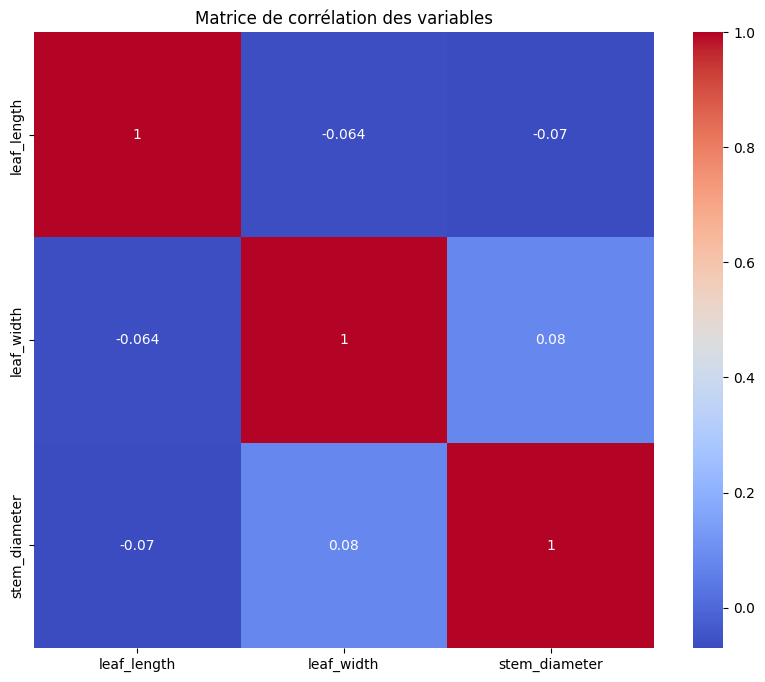

In [92]:
# Figure Size
plt.figure(figsize=(10,8))

# define heatmap parameters
sns.heatmap(
    df.select_dtypes(include = ["int64", "float64"]).corr(),
    cmap = "coolwarm", 
    annot = True
)

plt.title("Matrice de corrélation des variables")
plt.show()

On utilise un **Label Encoding** simple pour les variables catégorielles, ce qui est suffisant pour un Decision Tree.

In [93]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
for col in df.columns:
    if df[col].dtype == "object":
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col])
        encoders[col] = encoder

## 5. Séparation des données (features / target)

In [94]:
# define the target of the dataset
target = ['disease_type']

# Split data to features and target
X = df.drop(target,axis=1) # X for Features
y = df[target] # y for Target

## 6. Division entraînement (train) / évaluation (test)

In [95]:
# Split train and test for Features and Target
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 7. Entraînement du modèle Decision Tree

In [96]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42, criterion='entropy')
classifier.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 7.1 Courbes ROC et AUC (multiclasse)

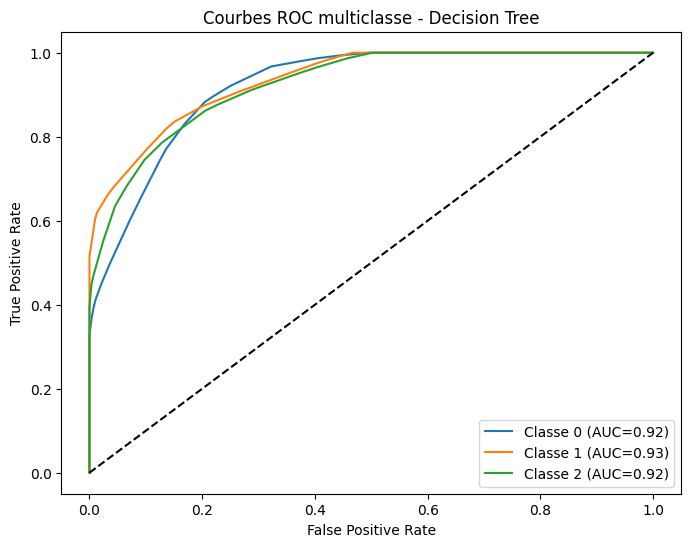

In [97]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Define best model for the train
best_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

best_model.fit(X_train, y_train)

# ROC and AUC curves 
classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=classes)

y_score = best_model.predict_proba(X_train)

plt.figure(figsize=(8,6))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_train_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Classe {class_label} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC multiclasse - Decision Tree")
plt.legend()
plt.show()


## 8. Évaluation du modèle

### 8.1 Définition de la variable de prédiction de target (y_pred)

In [98]:
y_pred = classifier.predict(X_test)

### 8.2 Matrice de confusion

La matrice de confusion permet d’analyser les erreurs de classification pour chaque classe et d’identifier les confusions fréquentes entre maladies.

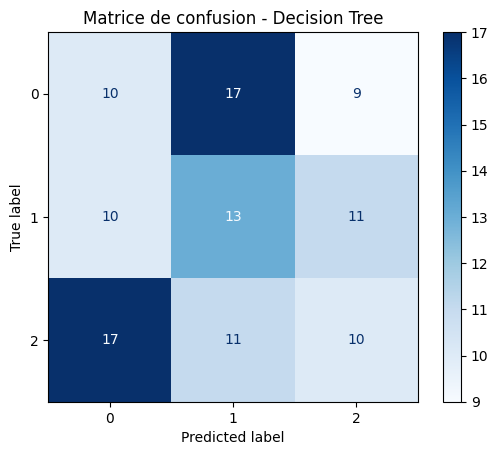

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Decision Tree")
plt.show()

### 8.3 Score de précision

In [100]:
from sklearn.metrics import accuracy_score

print('Accuracy :', accuracy_score(y_test, y_pred))

Accuracy : 0.3055555555555556


### 8.4 Rapport de classification

In [101]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.27      0.28      0.27        36
           1       0.32      0.38      0.35        34
           2       0.33      0.26      0.29        38

    accuracy                           0.31       108
   macro avg       0.31      0.31      0.30       108
weighted avg       0.31      0.31      0.30       108



### 8.5 Courbes ROC et AUC (multiclasse)

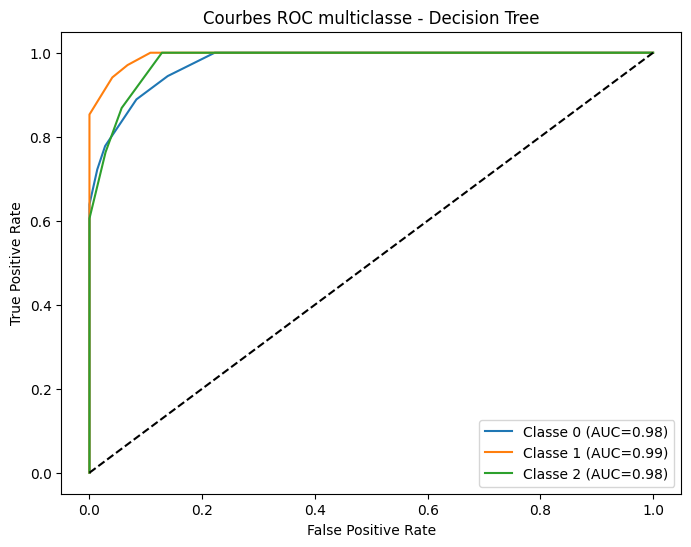

In [102]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Define best model for the test
best_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

best_model.fit(X_test, y_test)

# ROC and AUC curves
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Classe {class_label} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC multiclasse - Decision Tree")
plt.legend()
plt.show()


## 9. Optimisation du modèle (GridSearchCV)

Pour améliorer les performances, on optimise quelques hyperparamètres clés.

In [103]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_features': ['sqrt', 'log2'],
    'ccp_alpha': [0.1, 0.01, .001],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'ccp_alpha': [0.1, 0.01, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


## 10. Modèle optimisé et résultats finaux

In [104]:
best_model = grid.best_estimator_
y_pred_opt = best_model.predict(X_test)

print('Meilleurs paramètres :', grid.best_params_)
print('Accuracy optimisée :', accuracy_score(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

Meilleurs paramètres : {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2}
Accuracy optimisée : 0.46296296296296297
              precision    recall  f1-score   support

           0       0.44      0.44      0.44        36
           1       0.48      0.41      0.44        34
           2       0.47      0.53      0.49        38

    accuracy                           0.46       108
   macro avg       0.46      0.46      0.46       108
weighted avg       0.46      0.46      0.46       108



## 11. Sauvegarde du modèle et des encodeurs

In [105]:
# Saving Model and Encoders for the streamlit app
import joblib

joblib.dump(best_model, "decision_tree_model.pkl")


['decision_tree_model.pkl']

In [106]:
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']